# Imports

In [ ]:
df_macro_index_view = pd.read_csv("/Users/Thomas/Desktop/Master Thesis/Data/macro_indexs.csv")

# EDA for macro indexes

In [ ]:
# Correlation only for numeric financial columns
numeric_fin_cols = [
    "financial_risk_score",
    "Current_ratio",
    "Gearing",
    "Long_term_Gearing",
    "Short_term_Gearing",
    "Debt_Asset_ratio",
    "Interest_coverage_ratio",
    "Solvency_ratio_Asset_based",
    "Long_term_liabilities_Equity_ratio",
    "Short_term_liabilities_Equity_ratio",
    "Profit_margin",
    "EBIT_margin",
    "ROE_using_Net_income",
    "ROA_using_Net_income",
]

corr = df_financials[numeric_fin_cols].corr().abs()

high_corr_pairs = (
    corr.where(~np.tril(np.ones(corr.shape)).astype(bool))
        .stack()
        .reset_index()
)
high_corr_pairs.columns = ["feature_1", "feature_2", "abs_corr"]
high_corr_pairs = high_corr_pairs[high_corr_pairs["abs_corr"] >= 0.90].sort_values("abs_corr", ascending=False)

display(high_corr_pairs)

,feature_1,feature_2,abs_corr
151,Profit_margin,EBIT_margin,0.92021


In [ ]:
df_macro_index_view.head()

,Unnamed: 0,Country,Code,LPI_Score,Customs,Infrastructure,International_Shipments,Logistics_Competence,Tracking_Tracing,Timeliness,Year,PPI_Value
0,0,Afghanistan,AFG,1.211669,1.300000,1.100000,1.222220,1.250000,1.000000,1.375000,2007,NaN
1,1,Afghanistan,AFG,2.243160,2.223085,1.873596,2.244916,2.090449,2.365503,2.605503,2010,NaN
2,2,Afghanistan,AFG,2.297272,2.333617,2.003611,2.332182,2.162592,2.095155,2.795259,2012,NaN
3,3,Afghanistan,AFG,2.069573,2.163453,1.818951,1.986686,2.119709,1.847776,2.482138,2014,NaN
4,4,Afghanistan,AFG,1.948565,1.734900,1.807143,2.104431,1.919246,1.697024,2.382438,2018,NaN


In [ ]:
df_macro_index_view.info()

<class 'pandas.DataFrame'>
RangeIndex: 1635 entries, 0 to 1634
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               1635 non-null   int64  
 1   Country                  1635 non-null   str    
 2   Code                     915 non-null    str    
 3   LPI_Score                1499 non-null   float64
 4   Customs                  1499 non-null   float64
 5   Infrastructure           1499 non-null   float64
 6   International_Shipments  1499 non-null   float64
 7   Logistics_Competence     1499 non-null   float64
 8   Tracking_Tracing         1499 non-null   float64
 9   Timeliness               1499 non-null   float64
 10  Year                     1635 non-null   int64  
 11  PPI_Value                945 non-null    float64
dtypes: float64(8), int64(2), str(2)
memory usage: 153.4 KB


## Statistical Thresholds

In [ ]:
macro_cols = ['LPI_Score', 'Customs', 'Infrastructure', 'Logistics_Competence', 'PPI_Value']
stats_summary = df_macro_index_view[macro_cols].describe(percentiles=[.05, .1, .25, .5, .75, .9, .95])

print("--- Macro Threshold Reference Table ---")
print(stats_summary)

--- Macro Threshold Reference Table ---
         LPI_Score      Customs  Infrastructure  Logistics_Competence  \
count  1499.000000  1499.000000     1499.000000           1499.000000   
mean      3.032795     2.835961        2.920345              2.995885   
std       0.611014     0.641267        0.734737              0.664998   
min       1.211669     1.300000        1.100000              1.250000   
5%        2.158762     1.941180        1.900000              2.072016   
10%       2.300000     2.083330        2.045943              2.184993   
25%       2.527419     2.334031        2.333331              2.454945   
50%       2.920566     2.695652        2.762986              2.870897   
75%       3.600000     3.395238        3.598421              3.600000   
90%       3.942263     3.800000        4.043594              3.966859   
95%       4.023764     3.917559        4.171078              4.100000   
max       4.300000     4.207790        4.600000              4.400000   

        PP

## Temporal Analysis

Text(0.5, 1.0, 'Global Macroeconomic Trends (2011-2026)')

<Figure size 1500x1000 with 0 Axes>

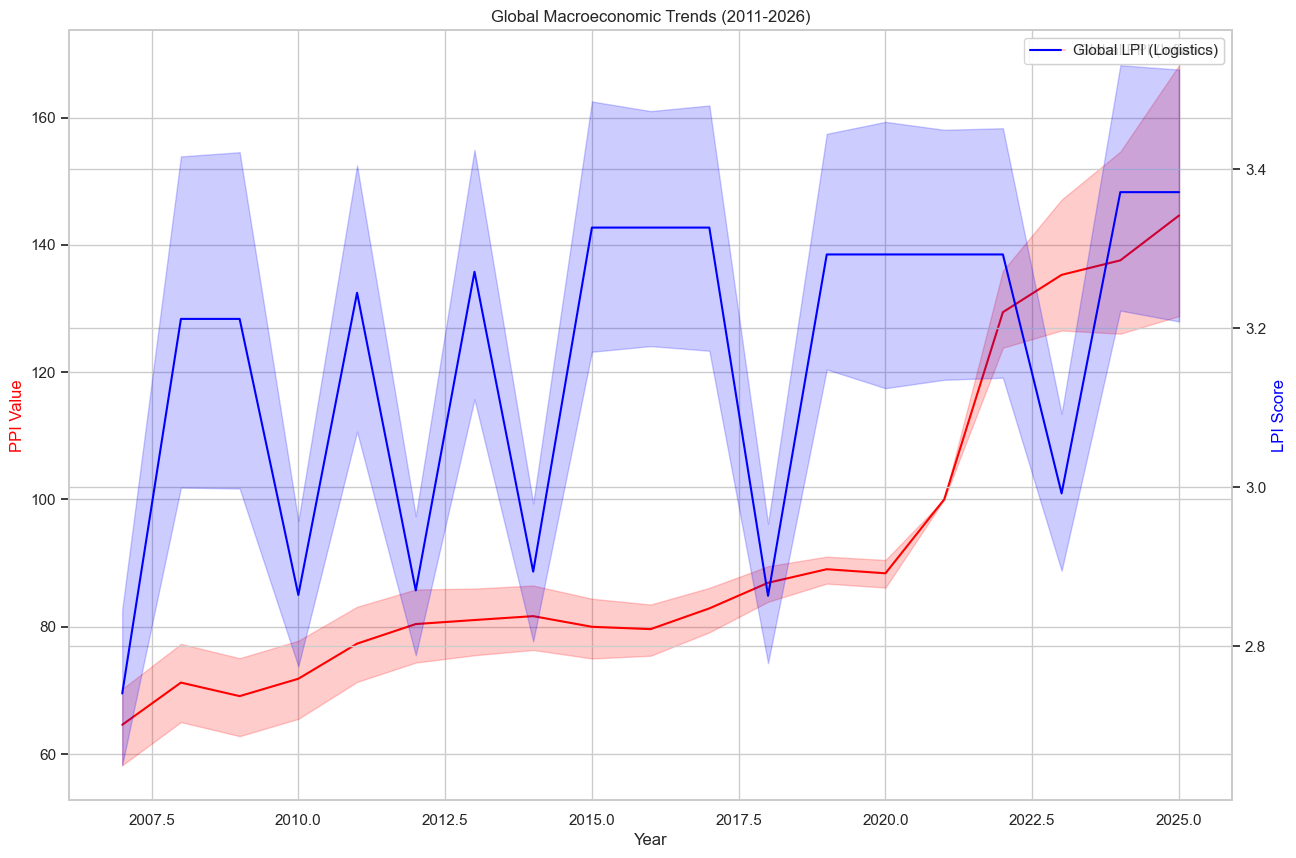

In [ ]:
plt.figure()
# Plotting the global average PPI and LPI over time
fig, ax1 = plt.subplots()

ax2 = ax1.twinx()
sns.lineplot(data=df_macro_index_view, x='Year', y='PPI_Value', ax=ax1, color='red', label='Global PPI (Inflation)')
sns.lineplot(data=df_macro_index_view, x='Year', y='LPI_Score', ax=ax2, color='blue', label='Global LPI (Logistics)')

ax1.set_ylabel('PPI Value', color='red')
ax2.set_ylabel('LPI Score', color='blue')
plt.title('Global Macroeconomic Trends (2011-2026)')

## Correlation

Text(0.5, 1.0, 'Correlation between Logistics Dimensions')

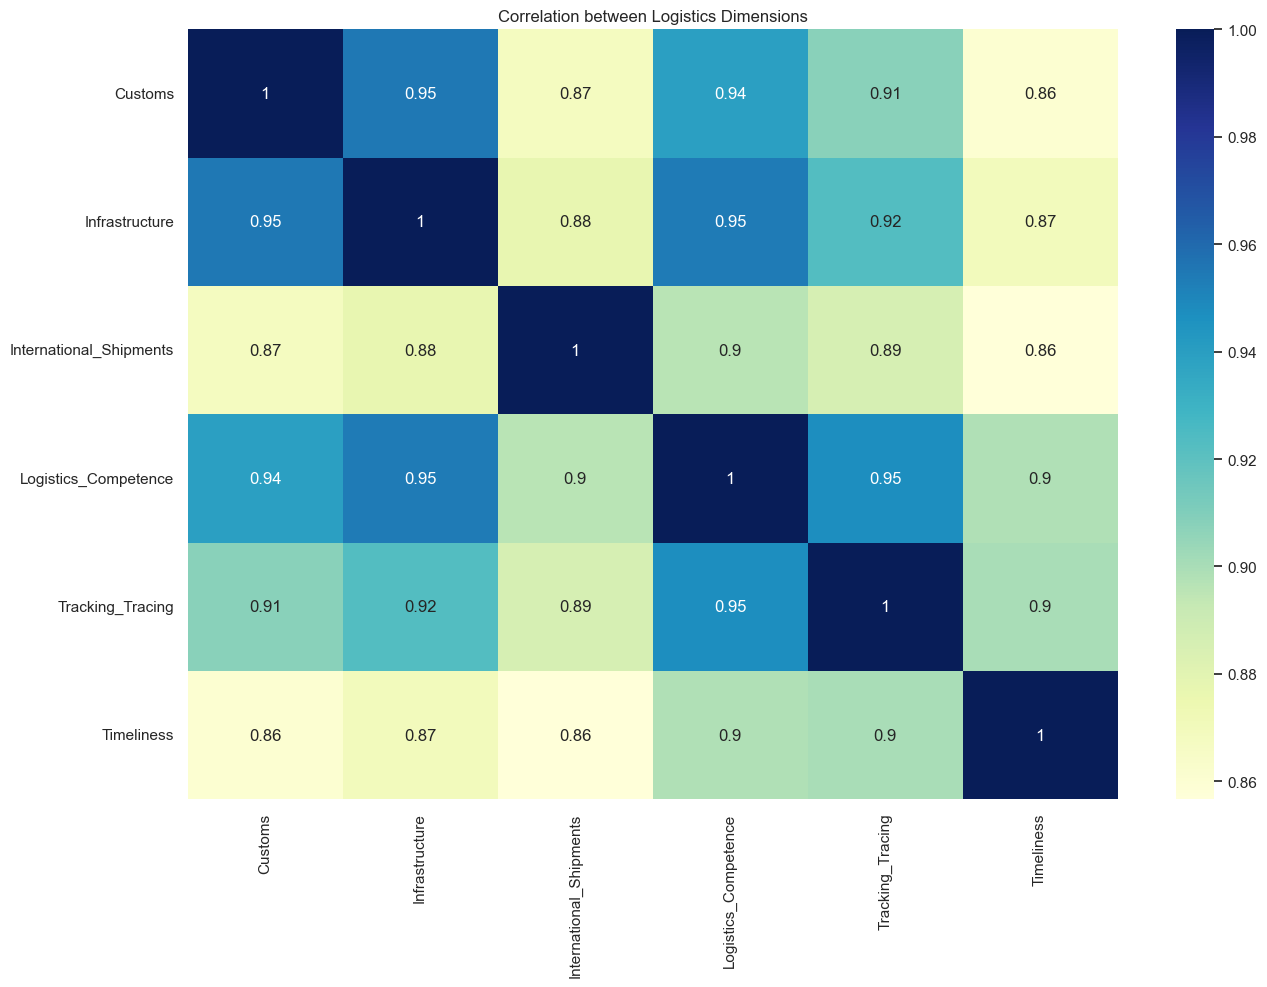

In [ ]:
lpi_dimensions = ['Customs', 'Infrastructure', 'International_Shipments', 'Logistics_Competence', 'Tracking_Tracing', 'Timeliness']
plt.figure()
sns.heatmap(df_macro_index_view[lpi_dimensions].corr(), annot=True, cmap='YlGnBu')
plt.title('Correlation between Logistics Dimensions')

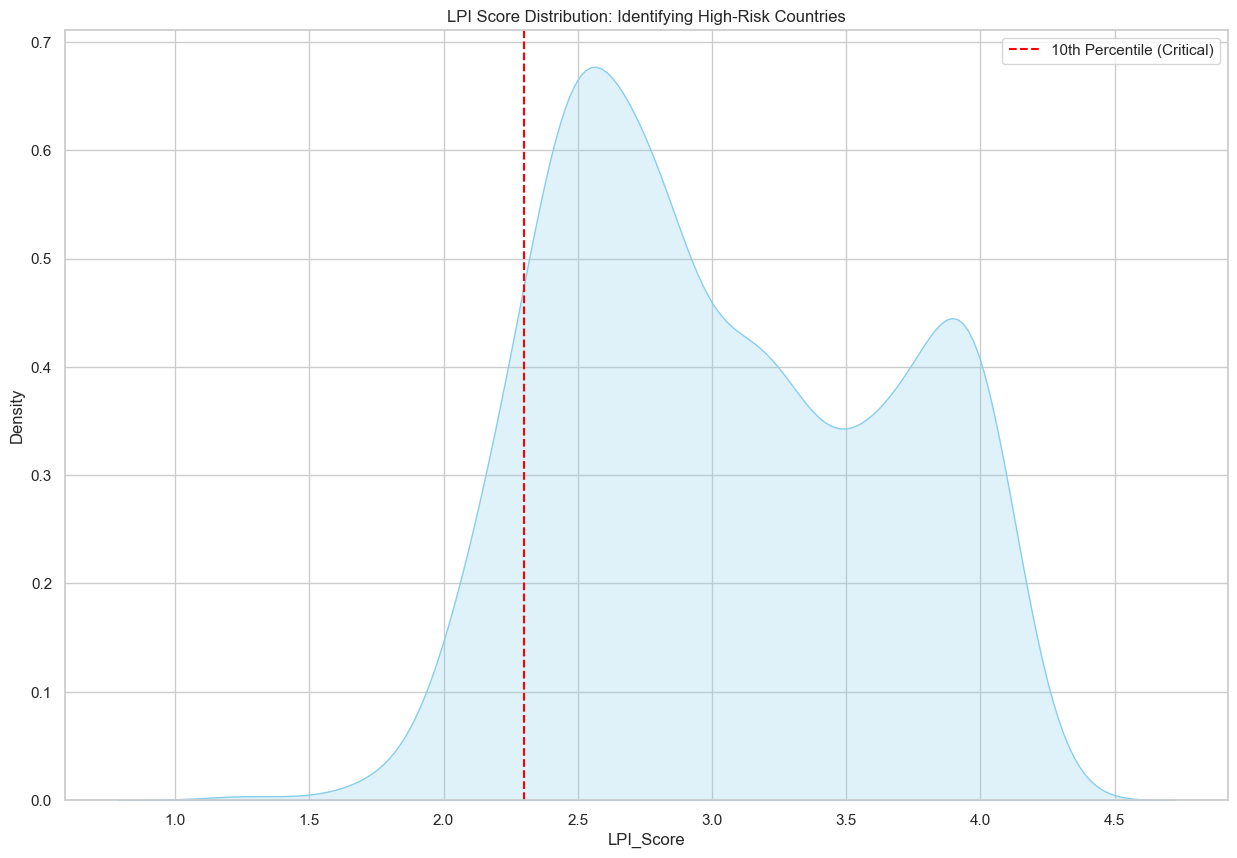

In [ ]:
plt.figure()
sns.kdeplot(data=df_macro_index_view, x='LPI_Score', fill=True, color="skyblue")
plt.axvline(df_macro_index_view['LPI_Score'].quantile(0.10), color='red', linestyle='--', label='10th Percentile (Critical)')
plt.title('LPI Score Distribution: Identifying High-Risk Countries')
plt.legend()

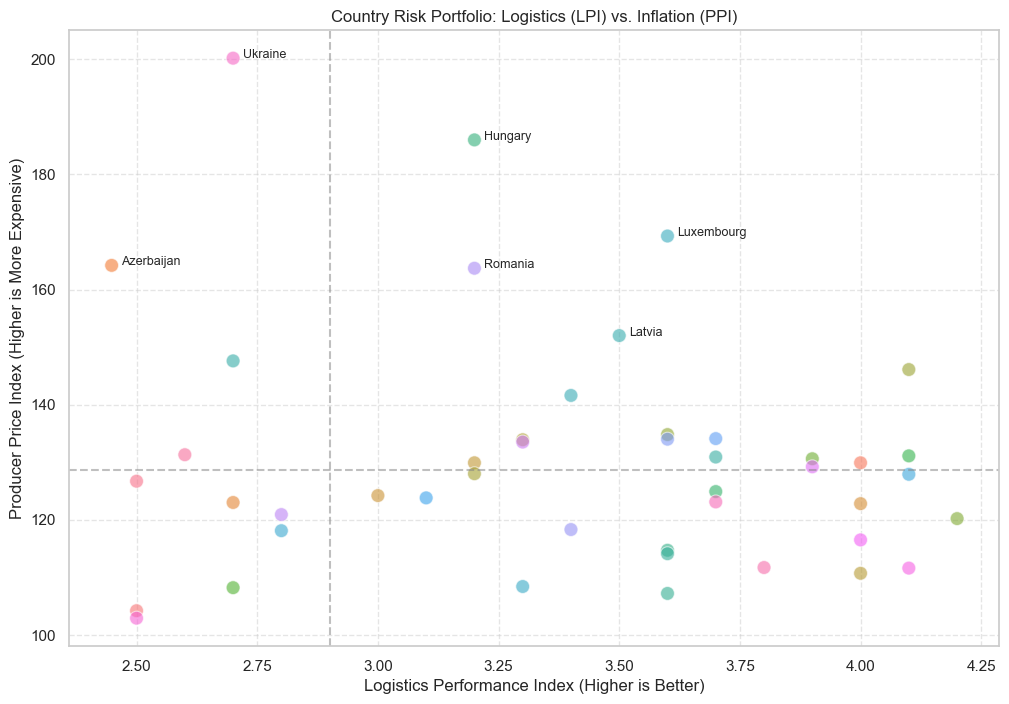

In [ ]:


# We aggregate the macro data to get one bubble per country for the latest year (e.g., 2023)
# We assume 'Exposure' is the count of occurrences in your dataset for this example
df_plot = df_macro_index_view[df_macro_index_view['Year'] == 2023].copy()
df_plot['Exposure'] = df_plot.groupby('Country')['Country'].transform('count')

plt.figure(figsize=(12, 8))

# Create the bubble chart
bubble = sns.scatterplot(
    data=df_plot.dropna(subset=['LPI_Score', 'PPI_Value']),
    x='LPI_Score', 
    y='PPI_Value',
    size='Exposure',
    hue='Country',  # Or 'Region' if you have that column
    sizes=(100, 2000), # Adjust bubble size range
    alpha=0.6,
    legend=False
)

# Label the top risk countries manually for the thesis
for i in range(df_plot.shape[0]):
    # Label if LPI is very low or PPI is very high (The Red Zone)
    if df_plot.LPI_Score.iloc[i] < 2.5 or df_plot.PPI_Value.iloc[i] > 150:
        plt.text(
            df_plot.LPI_Score.iloc[i]+0.02, 
            df_plot.PPI_Value.iloc[i]+0.02, 
            df_plot.Country.iloc[i], 
            fontsize=9
        )

plt.title('Country Risk Portfolio: Logistics (LPI) vs. Inflation (PPI)')
plt.xlabel('Logistics Performance Index (Higher is Better)')
plt.ylabel('Producer Price Index (Higher is More Expensive)')
plt.grid(True, linestyle='--', alpha=0.5)

# Add quadrants
plt.axvline(x=df_plot['LPI_Score'].median(), color='grey', linestyle='--', alpha=0.5)
plt.axhline(y=df_plot['PPI_Value'].median(), color='grey', linestyle='--', alpha=0.5)

